# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor, Booster
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.linear_model import Ridge
import shap
import json
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# 1. Loading Dataset

In [2]:
df = pd.read_csv('engineered_features.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (8784, 24)

Column names:
['datetime', 'us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'hour_sin', 'wind_u', 'wind_v', 'pm2_5_rolling_mean_36h', 'carbon_monoxide_rolling_mean_36h', 'pm10_rolling_mean_36h', 'pm2_5_rolling_std_72h', 'pm10_rolling_std_72h', 'aqi_change_rate', 'pm_ratio', 'is_rush_hour', 'precip_likelihood']

Missing values:
datetime                             0
us_aqi                               0
pm2_5                                0
pm10                                 0
carbon_monoxide                      0
nitrogen_dioxide                     0
sulphur_dioxide                      0
ozone                                0
uv_index                             0
temperature_2m                       0
relative_humidity_2m                 0
wind_speed_10m                       0
hour_sin                             0
wind_u              

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   datetime                          8784 non-null   str    
 1   us_aqi                            8784 non-null   int64  
 2   pm2_5                             8784 non-null   float64
 3   pm10                              8784 non-null   float64
 4   carbon_monoxide                   8784 non-null   float64
 5   nitrogen_dioxide                  8784 non-null   float64
 6   sulphur_dioxide                   8784 non-null   float64
 7   ozone                             8784 non-null   float64
 8   uv_index                          8784 non-null   float64
 9   temperature_2m                    8784 non-null   float64
 10  relative_humidity_2m              8784 non-null   int64  
 11  wind_speed_10m                    8784 non-null   float64
 12  hour_sin         

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])

if df['datetime'].dt.tz is not None:
    df['datetime'] = df['datetime'].dt.tz_localize(None)

current_time = pd.Timestamp.now()
df = df[df['datetime'] < current_time]

df.sort_values('datetime', ascending=True, inplace=True)

# 2. Creating Target

In [5]:
# # Create target column (next hour's pm 2.5) and remove rows with missing values
df['target'] = df['us_aqi'].shift(-1)
df = df.ffill()
df = df.dropna()
df = df.bfill()

print(f"Data after creating target column:")
print(f"Shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nSum of NaN: {df.isna().sum().sum()}")

Data after creating target column:
Shape: (8712, 25)

Column names:
['datetime', 'us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'hour_sin', 'wind_u', 'wind_v', 'pm2_5_rolling_mean_36h', 'carbon_monoxide_rolling_mean_36h', 'pm10_rolling_mean_36h', 'pm2_5_rolling_std_72h', 'pm10_rolling_std_72h', 'aqi_change_rate', 'pm_ratio', 'is_rush_hour', 'precip_likelihood', 'target']

Sum of NaN: 0


# 3. Train Test Split

In [6]:
n = len(df)
split_idx = int(n * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# Prepare features and target
drop_cols = ['datetime', 'target', 'us_aqi']
cols_to_drop = [c for c in drop_cols if c in df.columns]

X = df.drop(cols_to_drop, axis=1)
y = df['target']

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Total rows: {n}")
print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Total rows: 8712
Train rows: 6969, Test rows: 1743
X_train: (6969, 22), X_test: (1743, 22)
y_train: (6969,), y_test: (1743,)


In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_train_scaled min: {X_train_scaled.min().min():.4f}, max: {X_train_scaled.max().max():.4f}")
print(f"X_test_scaled min: {X_test_scaled.min().min():.4f}, max: {X_test_scaled.max().max():.4f}")


X_train_scaled shape: (6969, 22)
X_test_scaled shape: (1743, 22)
X_train_scaled min: 0.0000, max: 1.0000
X_test_scaled min: -0.0706, max: 1.0074


In [8]:
def calculate_metrics(y_pred, y_true, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'name': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

In [9]:
model_metrics = []

# 1. Random Forest Regression
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=200, 
                                 max_depth=15, 
                                 max_features=0.7, 
                                 min_samples_split=5,
                                 min_samples_leaf=4,
                                 random_state=42, 
                                 n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)
model_metrics.append(calculate_metrics(rf_test_pred, y_test, "Random Forest"))
print(f"Random Forest R²: {model_metrics[-1]['r2']:.4f}\n")

# 2. Gradient Boosting
print("Training Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(n_estimators=100,
    learning_rate=0.5,
    max_depth=3,
    min_samples_split=15,
    min_samples_leaf=5,
    subsample=0.7,
    random_state=42)

gb_model.fit(X_train_scaled, y_train)
gb_train_pred = gb_model.predict(X_train_scaled)
gb_test_pred = gb_model.predict(X_test_scaled)
model_metrics.append(calculate_metrics(gb_test_pred, y_test, "Gradient Boosting"))
print(f"Gradient Boosting R²: {model_metrics[-1]['r2']:.4f}\n")


# 3. XGBoost
print("Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=200, 
                         max_depth=3, 
                         learning_rate=0.05,
                         subsample=0.8, 
                         colsample_bytree=0.7, 
                         min_child_weight=5,
                         gamma=0.5,
                         random_state=42,
                         n_jobs=-1

                         )
xgb_model.fit(X_train_scaled, y_train)
xgb_train_pred = xgb_model.predict(X_train_scaled)
xgb_test_pred = xgb_model.predict(X_test_scaled)
model_metrics.append(calculate_metrics(xgb_test_pred, y_test, "XGBoost"))
print(f"XGBoost R²: {model_metrics[-1]['r2']:.4f}\n")


# 4. Support Vector Regressor
print("Training Support Vector Regressor...")
svr_model = SVR(kernel='rbf', C=10, gamma=0.001, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)
model_metrics.append(calculate_metrics(svr_test_pred, y_test, "SVR"))
print(f"SVR R²: {model_metrics[-1]['r2']:.4f}\n")

# 5. Ridge Regression
print("Training Ridge Regression...")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)
model_metrics.append(calculate_metrics(ridge_test_pred, y_test, "Ridge Regression"))
print(f"Ridge Regression  R²: {model_metrics[-1]['r2']:.4f}\n")

# 6. LSTM
# print("Training LSTM...")
# X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
# X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# lstm_model_light = Sequential([
#     LSTM(32, activation='tanh', input_shape=(X_train_lstm.shape[1], 1)), # Single layer, tanh for speed
#     Dropout(0.2),
#     Dense(16, activation='relu'),
#     Dense(1)
# ])

# lstm_model_light.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Training with a much larger batch size speeds up epochs drastically
# lstm_model_light.fit(
#     X_train_lstm, y_train, 
#     epochs=50, 
#     batch_size=128,    # Increased from 16 to 128
#     validation_split=0.2, 
#     verbose=0, 
#     callbacks=[early_stop]
# )

# lstm_train_pred = lstm_model_light.predict(X_train_lstm, verbose=0).flatten()
# lstm_test_pred = lstm_model_light.predict(X_test_lstm, verbose=0).flatten()
# model_metrics.append(calculate_metrics(lstm_train_pred, y_train, "LSTM (Train)"))
# model_metrics.append(calculate_metrics(lstm_test_pred, y_test, "LSTM (Test)"))
# print(f"LSTM R²: {model_metrics[-2]['r2']:.4f}, Test R²: {model_metrics[-1]['r2']:.4f}\n")

print("Best Models Ranking:")
test_metrics = pd.DataFrame(model_metrics)
test_metrics = test_metrics[['name', 'r2', 'rmse', 'mae']].sort_values(by=['r2', 'rmse', 'mae'], ascending=False)
print(test_metrics.to_string(index=False))

Training Random Forest Regressor...
Random Forest R²: 0.8346

Training Gradient Boosting Regressor...
Gradient Boosting R²: 0.8278

Training XGBoost...
XGBoost R²: 0.8496

Training Support Vector Regressor...
SVR R²: 0.5093

Training Ridge Regression...
Ridge Regression  R²: 0.8281

Best Models Ranking:
             name       r2      rmse       mae
          XGBoost 0.849649  7.410443  4.653060
    Random Forest 0.834592  7.772640  4.821798
 Ridge Regression 0.828062  7.924580  5.040357
Gradient Boosting 0.827770  7.931304  5.201750
              SVR 0.509348 13.386814 10.347506


# 4. Prediction For Next 72 Hours

In [10]:
import pandas as pd
import numpy as np

def forecast_72_hours(df, xgb_model, features):
    """
    Perform a 72-hour iterative forecast using an XGBoost model.
    
    Parameters:
    df (pd.DataFrame): Historical dataframe containing 'datetime', 'us_aqi', and other features.
    xgb_model: Your trained XGBoost model.
    features (list): The list of feature columns required for the model prediction.
    """
    # Create a working copy of the dataframe
    sim_df = df.copy()
    
    # Ensure datetime is sorted and correctly formatted
    if not np.issubdtype(sim_df['datetime'].dtype, np.datetime64):
        sim_df['datetime'] = pd.to_datetime(sim_df['datetime'])
    sim_df = sim_df.sort_values('datetime').reset_index(drop=True)
    
    target_var = 'us_aqi'
    rolling_mean_windows = [36]
    rolling_std_windows = [72]
    lag = []
    
    predictions = []
    
    # Iterate for the next 72 hours
    for step in range(72):
        last_row = sim_df.iloc[-1].copy()
        next_time = last_row['datetime'] + pd.Timedelta(hours=1)
        
        # 1. Forward-fill static or exogenous features (like weather, pollutants) from the last known row
        new_row = last_row.copy()
        new_row['datetime'] = next_time
        
        # Set the target variable to NaN temporarily for the new row
        new_row[target_var] = np.nan
        
        # Append the new row to the dataframe
        sim_df = pd.concat([sim_df, pd.DataFrame([new_row])], ignore_index=True)
        
        # 2. Update time-based cyclical features for the new forecasted hour
        sim_df.loc[sim_df.index[-1], 'hour_cos'] = np.cos(2 * np.pi * next_time.hour / 24)
        sim_df.loc[sim_df.index[-1], 'hour_sin'] = np.sin(2 * np.pi * next_time.hour / 24)
        sim_df.loc[sim_df.index[-1], 'day_of_week_sin'] = np.sin(2 * np.pi * next_time.dayofweek / 7)
        sim_df.loc[sim_df.index[-1], 'day_of_week_cos'] = np.cos(2 * np.pi * next_time.dayofweek / 7)
        sim_df.loc[sim_df.index[-1], 'month_sin'] = np.sin(2 * np.pi * next_time.month / 12)
        sim_df.loc[sim_df.index[-1], 'month_cos'] = np.cos(2 * np.pi * next_time.month / 12)
        
        # Example boolean features based on time
        sim_df.loc[sim_df.index[-1], 'is_rush_hour'] = 1 if next_time.hour in [7, 8, 9, 16, 17, 18, 19] else 0
        sim_df.loc[sim_df.index[-1], 'is_workday'] = 1 if next_time.dayofweek < 5 else 0
        
        # 3. Dynamically apply your exact formulas to recalculate lags, rolling means, and standard deviations
        var = ['pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'pm10']
        for win in rolling_mean_windows:
            for vr in var:
                sim_df[f'{vr}_rolling_mean_{win}h'] = sim_df[vr].rolling(window=win).mean().shift(1)

        for win in rolling_std_windows:
            for vr in var:
                sim_df[f'{vr}_rolling_std_{win}h'] = sim_df[vr].rolling(window=win).std().shift(1)
        
        var = ['us_aqi', 'pm2_5']
        for lg in lag:
            for vr in var:
                sim_df[f'{vr}_lag{lg}h'] = sim_df[vr].shift(lg)
        
        var = 'us_aqi'
        # Re-calculate other dynamic ratios based on the updated dataframe
        sim_df['pm_ratio'] = sim_df['pm2_5'] / (sim_df['pm10'] + 1e-5)
        sim_df['aqi_change_rate'] = (sim_df[var].shift(1) - sim_df[var].shift(2)) / (sim_df[var].shift(2) + 1e-5)
        sim_df.dropna()
        
        # 4. Extract the feature vector for the current prediction (the last appended row)
        X_pred = sim_df[features].iloc[[-1]]
        X_pred = scaler.transform(X_pred)
        # 5. Predict using the XGBoost model
        # Note: Apply scaling here if your model requires X_pred to be scaled first (e.g., scaler.transform(X_pred))
        pred_val = xgb_model.predict(X_pred)[0]
        
        # 6. Fill the prediction back into the dataframe to be used as history in the next iteration
        sim_df.at[sim_df.index[-1], target_var] = pred_val
        
        # Store prediction result
        predictions.append({'datetime': next_time, 'predicted_us_aqi': pred_val})
        
    return pd.DataFrame(predictions), sim_df


# 5. Results

In [11]:
# Calculate daily averages for observed data and forecasts

# Observed daily averages (pm2_5 and US AQI)
obs_df = df.copy()
obs_df['date'] = obs_df['datetime'].dt.date
observed_daily = (
    obs_df.groupby('date')
    .agg(us_aqi_mean=('us_aqi', 'mean'))
    .reset_index()
)

feature_cols = X.columns
pred72_df, updated_sim_df = forecast_72_hours(df, gb_model, feature_cols)

print(pred72_df.to_string(index=False))

           datetime  predicted_us_aqi
2026-05-27 00:00:00         70.510083
2026-05-27 01:00:00         70.786927
2026-05-27 02:00:00         70.786927
2026-05-27 03:00:00         66.997360
2026-05-27 04:00:00         69.607604
2026-05-27 05:00:00         69.607604
2026-05-27 06:00:00         69.607604
2026-05-27 07:00:00         69.670256
2026-05-27 08:00:00         69.670256
2026-05-27 09:00:00         69.292399
2026-05-27 10:00:00         69.229747
2026-05-27 11:00:00         67.184985
2026-05-27 12:00:00         67.947217
2026-05-27 13:00:00         67.947217
2026-05-27 14:00:00         66.923009
2026-05-27 15:00:00         67.705201
2026-05-27 16:00:00         67.767852
2026-05-27 17:00:00         67.780192
2026-05-27 18:00:00         67.280566
2026-05-27 19:00:00         70.511165
2026-05-27 20:00:00         70.604655
2026-05-27 21:00:00         70.604655
2026-05-27 22:00:00         68.467654
2026-05-27 23:00:00         68.467654
2026-05-28 00:00:00         63.588742
2026-05-28 0

In [12]:
# 72-hour forecast daily averages
pred72_daily = pred72_df.copy()
pred72_daily['date'] = pred72_daily['datetime'].dt.date
pred72_daily = (
    pred72_daily.groupby('date')
    .agg(us_aqi_mean=('predicted_us_aqi', 'mean'))
    .reset_index()
)


print("\n72h forecast daily averages:")
print(pred72_daily.to_string(index=False))


72h forecast daily averages:
      date  us_aqi_mean
2026-05-27    68.956616
2026-05-28    61.567495
2026-05-29    61.019077


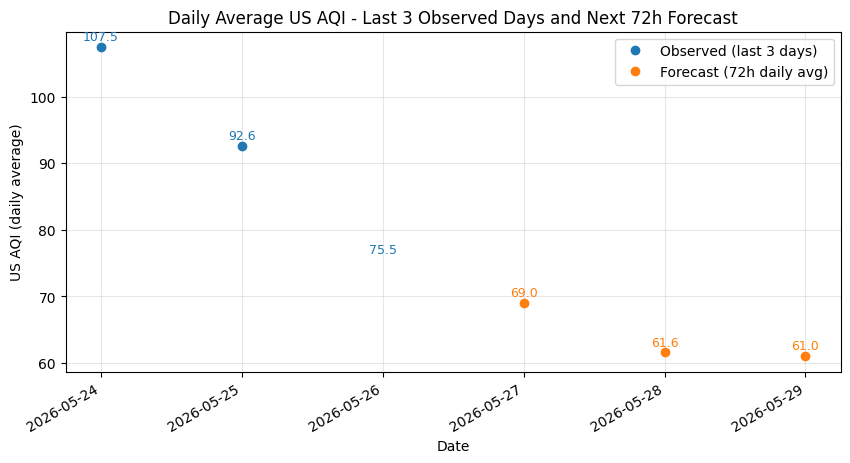

In [13]:
last3_obs = observed_daily.sort_values('date').tail(3).copy()
pred_daily = pred72_daily.copy()

last3_obs['date'] = pd.to_datetime(last3_obs['date'])
pred_daily['date'] = pd.to_datetime(pred_daily['date'])

plt.figure(figsize=(10,5))
plt.plot(last3_obs['date'][:-1], last3_obs['us_aqi_mean'][:-1], marker='o', linestyle=' ', color='tab:blue', label='Observed (last 3 days)')
plt.plot(pred_daily['date'], pred_daily['us_aqi_mean'], marker='o', linestyle=' ', color='tab:orange', label='Forecast (72h daily avg)')

for x, y in zip(last3_obs['date'], last3_obs['us_aqi_mean']):
    plt.text(x, y+1, f"{y:.1f}", ha='center', fontsize=9, color='tab:blue')
for x, y in zip(pred_daily['date'], pred_daily['us_aqi_mean']):
    plt.text(x, y+1, f"{y:.1f}", ha='center', fontsize=9, color='tab:orange')

plt.xlabel('Date')
plt.ylabel('US AQI (daily average)')
plt.title('Daily Average US AQI - Last 3 Observed Days and Next 72h Forecast')
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# 6. SHAP Analysis

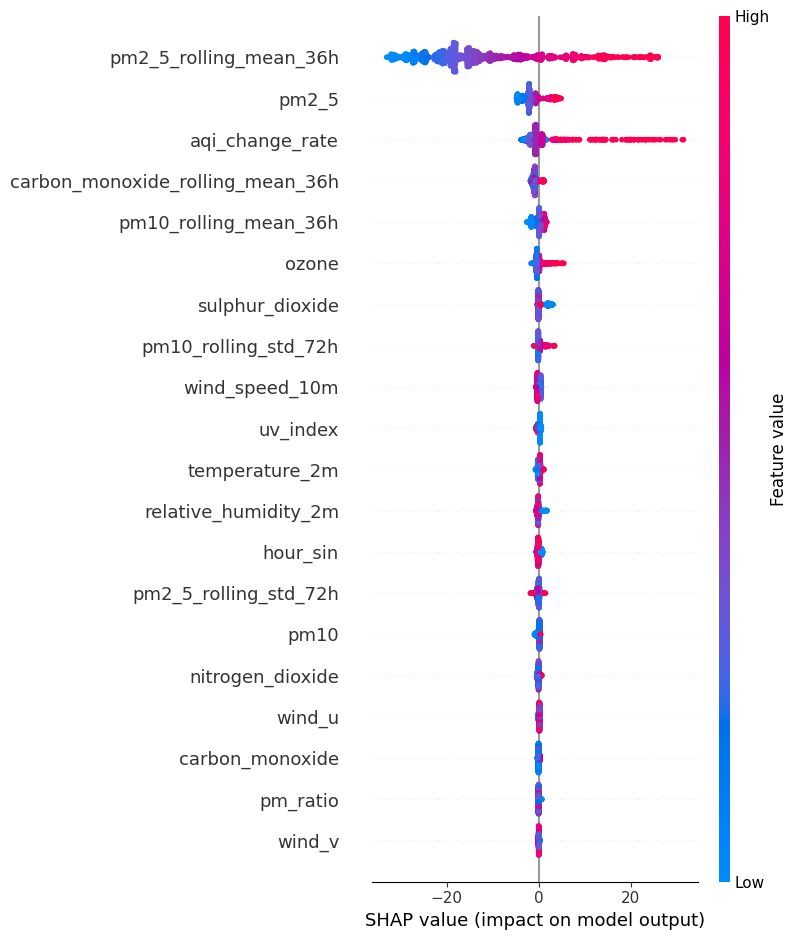

In [14]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

raw_booster = xgb_model.get_booster()
config = json.loads(raw_booster.save_config())

# Extract and clean the base_score string
base_score_val = config["learner"]["learner_model_param"]["base_score"]
if isinstance(base_score_val, str) and base_score_val.startswith("["):
    clean_score = float(base_score_val.strip("[]"))
    # Update the dictionary parameter value
    config["learner"]["learner_model_param"]["base_score"] = str(clean_score)

# Save the updated configuration back to a new Booster object
cleaned_booster = Booster()
cleaned_booster.load_model(raw_booster.save_raw())
# Force-inject the sanitized parameter configuration string
cleaned_booster.load_config(json.dumps(config))

# 3. Create explainer using the completely sanitized booster object
explainer = shap.TreeExplainer(cleaned_booster)
shap_values = explainer.shap_values(X_test_scaled_df)  # shape: (n_samples, n_features)

# 5. SHAP summary plots
shap.summary_plot(shap_values, X_test_scaled_df, show=True)

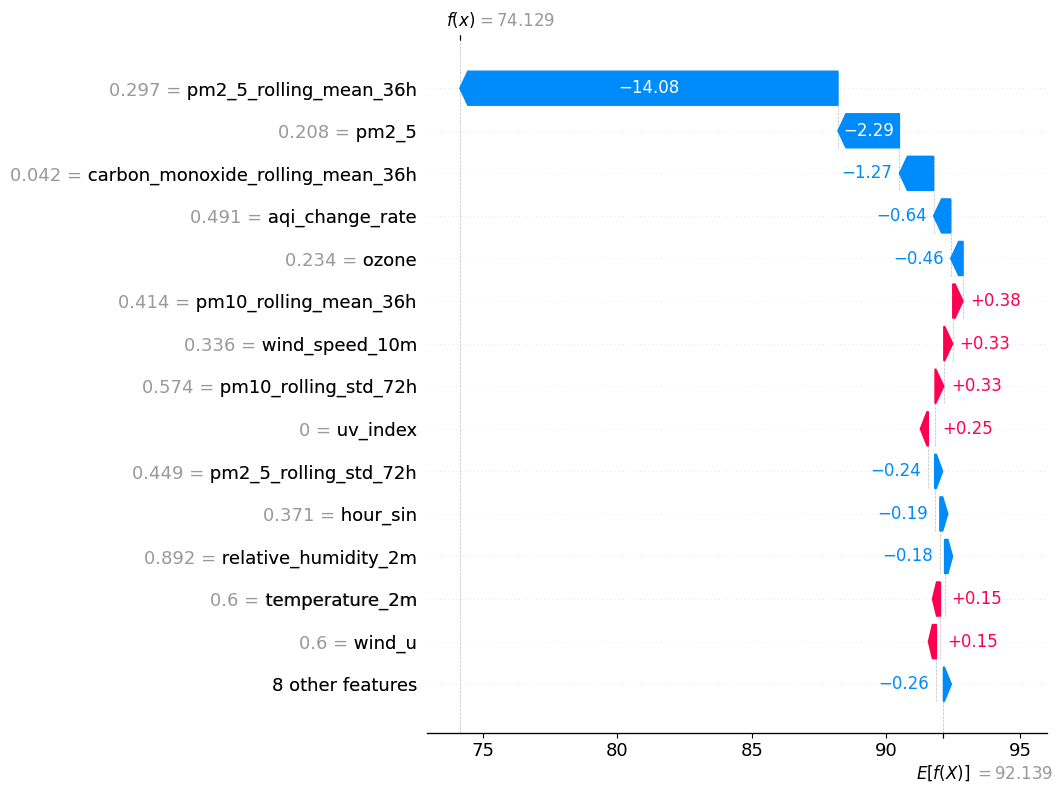

In [15]:
sample_idx = X_test_scaled_df.shape[0] - 1

expl = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled_df.iloc[sample_idx].values,
    feature_names=X_test_scaled_df.columns.tolist()
)

# Plot waterfall
shap.plots.waterfall(expl, max_display=15, show=True)

## 6.1. Conclusion

### Beeswarm Plot

* Historical PM2.5 is the Dominant Driver: High values of the 36-hour rolling mean strongly increase the model's output. Conversely, low values strongly decrease the prediction.

* PM 2.5: pm2_5 is the second most important feature, behaving similarly to the rolling mean but with a slightly narrower impact range.

* AQI Change Rate: a sudden spike in AQI change rate acts as a strong warning signal for a high final prediction.

* Features like pm10_rolling_mean_36h, carbon_monoxide_rolling_mean_36h, and ozone have moderate, predictable impacts. High values generally lead to higher predictions, but their maximum impact is much smaller than PM2.5.


### Waterfall Plot

historical pollution levels over the last 36 hours were quite high (which drastically raised the prediction), but the current situation is stabilizing or improving (indicated by the negative SHAP values from the current PM2.5 and the AQI change rate). The model balanced these out to land at 103.63.